<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Introduction-to-Machine-Learning-with-Python/blob/main/07_working_with_text_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Working with text data and natural language processing**
This notebook covers working with text data and natural language processing:

1. Types of Data Represented as Strings and Example Application
2. Representing Text Data as a Bag of Words
3. Stopwords and Rescaling the Data with tf-idf
4. Investigating Model Coefficients and n-Grams
5. Advanced Tokenization, Stemming, and Lemmatization
6. Topic Modeling and Document Clustering (LDA)
7. Summary

## **Setup**

In [1]:
!pip install -q datasets nltk mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 7.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Patch mglearn.tools.heatmap for numpy/matplotlib compatibility
import mglearn.tools as _mt
def _patched_heatmap(values, xlabel, ylabel, xticklabels, yticklabels,
                     cmap=None, vmin=None, vmax=None, ax=None, fmt="%0.2f"):
    if ax is None:
        ax = plt.gca()
    values = np.array(values, dtype=np.float64)
    img = ax.pcolor(values, cmap=cmap, vmin=vmin, vmax=vmax)
    img.update_scalarmappable()
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(np.arange(len(xticklabels)) + .5)
    ax.set_yticks(np.arange(len(yticklabels)) + .5)
    ax.set_xticklabels(xticklabels)
    ax.set_yticklabels(yticklabels)
    ax.set_aspect(1)
    for p, color, value in zip(img.get_paths(), img.get_facecolors(),
                               values.ravel()):
        x, y = p.vertices[:-2, :].mean(0)
        c = 'k' if np.mean(color[:3]) > 0.5 else 'w'
        ax.text(x, y, fmt % float(value), color=c, ha="center", va="center")
    return img
_mt.heatmap = _patched_heatmap

## **Introduction**

Beyond the continuous and categorical features previously discussed in Chapter 4, text data emerges as a crucial third category that plays a pivotal role in various practical applications, from sentiment analysis in political discourse to automated customer intent classification. Unlike structured numeric data, text is typically represented as variable-length strings, making it inherently more complex and distinct in nature. Consequently, because machine learning algorithms require numerical input, this type of data necessitates specialized preprocessing and transformation—such as vectorization—to bridge the gap between raw linguistic content and the mathematical frameworks we use for our models.

## **1. Types of Data Represented as Strings**

Prior to implementing the preprocessing pipelines for machine learning, it is essential to distinguish between the various types of string data we may encounter. While text is typically stored as a string, not every string feature should be treated as natural language. As we explored previously, strings can often represent categorical variables, and determining the appropriate treatment requires a thorough initial inspection of the data.

Generally, string data can be classified into four distinct categories:
- Categorical data: Originating from fixed sets (e.g., a predefined drop-down menu).
- Free strings mapable to categories: Manual entries that can be grouped semantically.
- Structured string data: Information with specific formats, such as addresses or IDs.
- Freeform text data: Complex structures like sentences or full documents.

The complexity increases significantly when users are given an open text field. In this scenario, we encounter free strings ranging from standard names to highly idiosyncratic descriptions (e.g., the 'xkcd Color Survey' examples). Mapping these to categories often demands substantial manual effort and domain-specific logic, which underscores why we should prioritize fixed categorical inputs during the data collection phase whenever possible.

Lastly, we have freeform text, such as tweets or reviews, composed of phrases and sentences. In the fields of Natural Language Processing (NLP) and Information Retrieval (IR), we typically refer to the entire dataset as a corpus, while each individual entry is termed a document. Managing these requires a fundamentally different approach compared to simple categorical encoding.

### **1.1. Example Application: Sentiment Analysis of Movie Reviews**

In this chapter, we utilize a movie review dataset sourced from IMDb, originally compiled by Andrew Maas of Stanford University, which consists of review texts paired with binary labels. While the original platform employs a 1-to-10 rating scale, the dataset simplifies this into a two-class classification problem: reviews scoring 6 or above are categorized as 'positive,' while those below are marked as 'negative.' Although the efficacy of this threshold remains a point of discussion, we proceed with the data in its provided form, which is organized into training and testing directories, each further partitioned into 'pos' and 'neg' subfolders for streamlined processing.

We use the datasets library from Hugging Face to load the IMDb movie reviews dataset. This dataset contains 25,000 training reviews and 25,000 test reviews, each labeled as positive ($y = 1$) or negative ($y = 0$).

In [45]:
from datasets import load_dataset
from datasets import disable_progress_bar
disable_progress_bar()

# Load the IMDb dataset
imdb = load_dataset("imdb")

# Extract text and labels
text_train = imdb['train']['text']
y_train = np.array(imdb['train']['label'])

text_test = imdb['test']['text']
y_test = np.array(imdb['test']['label'])

print("type of text_train: {}".format(type(text_train)))
print("length of text_train: {}".format(len(text_train)))
print("text_train[1]:\n{}".format(text_train[1][:300]))

type of text_train: <class 'datasets.arrow_dataset.Column'>
length of text_train: 25000
text_train[1]:
"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity


The text_train dataset comprises 25,000 string entries, each representing an individual review, as evidenced by the sample retrieved at index 1. A preliminary inspection of the data reveals the presence of HTML artifacts, specifically < br /> tags, within the text. While such formatting is unlikely to significantly skew the performance of our machine learning models, adhering to rigorous data-cleaning protocols suggests that removing these elements is a necessary step to ensure a cleaner input before we proceed with the modeling phase.

In [4]:
# Clean HTML tags
text_train = [doc.replace("<br />", " ") for doc in text_train]
text_test = [doc.replace("<br />", " ") for doc in text_test]

The dataset was collected such that the positive class and the negative class balanced, so that there are as many positive as negative strings:

In [5]:
print("Samples per class (training): {}".format(np.bincount(y_train)))
print("Number of documents in test data: {}".format(len(text_test)))
print("Samples per class (test): {}".format(np.bincount(y_test)))

Samples per class (training): [12500 12500]
Number of documents in test data: 25000
Samples per class (test): [12500 12500]


Our primary objective involves a standard binary classification task where we aim to categorize reviews as either 'positive' or 'negative' based on their textual content. However, since raw text data is inherently incompatible with machine learning algorithms, we must first bridge this gap by transforming the string representations into a structured numeric format. This preprocessing step is essential to ensure that our models can effectively interpret and learn from the underlying patterns within the reviews.

## **2. Representing Text Data as a Bag of Words**

The Bag-of-Words (BoW) model remains one of the most fundamental yet highly effective techniques for representing textual data in machine learning. This approach essentially simplifies the input by disregarding its formal structure—such as paragraphs, sentence order, and formatting—focusing instead on the raw frequency of each word within the corpus. This conceptual shift, where we treat a document simply as a collection of word counts rather than a structured narrative, is precisely why it is referred to as a 'bag.'

To implement a BoW representation, we typically follow a three-step workflow:
1. Tokenization: Breaking down each document into individual components or 'tokens,' usually by using whitespace and punctuation as delimiters.
2. Vocabulary Construction: Compiling a comprehensive list of every unique word found across the entire dataset and assigning each a numerical index (often sorted alphabetically).
3. Encoding: Generating a count for every word in the vocabulary as it appears in a specific document.

While there are nuances in the initial stages—particularly regarding how we handle tokens and filter the vocabulary—the core process is straightforward. Using libraries like scikit-learn, we can transform a string, such as "This is how you get ants," into a feature vector. In this resulting numeric representation, each unique word in the dataset corresponds to a specific feature. It is important to note that in this model, the original sequence of words becomes entirely irrelevant; what matters is the quantitative presence of the terms themselves.

### **2.1. Applying Bag-of-Words to a Toy Dataset**

The bag-of-words representation is implemented in CountVectorizer, which is a
transformer. Let’s first apply it to a toy dataset, consisting of two samples, to see it working:

In [6]:
bards_words = ["The fool doth think he is wise,",
               "but the wise man knows himself to be a fool"]

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()
vect.fit(bards_words)

CountVectorizer()

Fitting the CountVectorizer consists of the tokenization of the training data and building of the vocabulary, which we can access as the vocabulary_ attribute:

In [8]:
print("Vocabulary size: {}".format(len(vect.vocabulary_)))
print("Vocabulary content:\n {}".format(vect.vocabulary_))

Vocabulary size: 13
Vocabulary content:
 {'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


The vocabulary consists of 13 words, from "be" to "wise". To create the bag-of-words representation for the training data, we call the transform
method:

In [9]:
bag_of_words = vect.transform(bards_words)
print("bag_of_words: {}".format(repr(bag_of_words)))

bag_of_words: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>


The resulting bag-of-words representation is efficiently managed as a $2 \times 13$ SciPy sparse matrix, where rows represent individual data points and columns correspond to unique vocabulary terms. Given that a typical document—much like a movie review—utilizes only a fraction of the entire English lexicon, the vast majority of potential feature entries remain zero. Utilizing a sparse format is therefore a critical memory-saving strategy, as storing these redundant zeros in a standard dense format would be computationally prohibitive. However, for a more direct inspection of the underlying data, we can readily project this matrix back into a conventional NumPy 'dense' array by employing the toarray() method.

In [10]:
print("Dense representation of bag_of_words:\n{}".format(
    bag_of_words.toarray()))

Dense representation of bag_of_words:
[[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


In this dataset, the word counts for each entry are binary—either 0 or 1—indicating that none of the strings in bards_words contain duplicate terms. When examining the feature vectors, the first row corresponds to the string 'The fool doth think he is wise,' where we can trace its composition against the vocabulary; for instance, it excludes the words 'be' and 'but' while including 'doth' exactly once. By comparing both rows, it becomes evident that certain terms such as 'fool,' 'the,' and 'wise' are shared across both strings, serving as common features in our vector space.

### **2.2. Bag-of-Words for Movie Reviews**

Now that we’ve gone through the bag-of-words process in detail, let’s apply it to our task of sentiment analysis for movie reviews. Earlier, we loaded our training and test data from the IMDb reviews into lists of strings (text_train and text_test), which we will now process:

In [11]:
vect = CountVectorizer().fit(text_train)
X_train = vect.transform(text_train)
print("X_train:\n{}".format(repr(X_train)))

X_train:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3431196 stored elements and shape (25000, 74849)>


The X_train matrix, which represents our training data in a bag-of-words format, consists of 25,000 samples and a vocabulary of 74,849 unique entries, all efficiently stored within a SciPy sparse matrix. To gain a deeper understanding of these features, we can utilize the get_feature_names() method from our vectorizer; this approach is particularly useful as it provides a structured list where each element directly maps to a specific feature in our dataset, allowing for a more detailed inspection of the underlying vocabulary.

In [12]:
feature_names = vect.get_feature_names_out()
print("Number of features: {}".format(len(feature_names)))
print("First 20 features:\n{}".format(feature_names[:20]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 2000th feature:\n{}".format(feature_names[::2000]))

Number of features: 74849
First 20 features:
['00' '000' '0000000000001' '00001' '00015' '000s' '001' '003830' '006'
 '007' '0079' '0080' '0083' '0093638' '00am' '00pm' '00s' '01' '01pm' '02']
Features 20010 to 20030:
['dratted' 'draub' 'draught' 'draughts' 'draughtswoman' 'draw' 'drawback'
 'drawbacks' 'drawer' 'drawers' 'drawing' 'drawings' 'drawl' 'drawled'
 'drawling' 'drawn' 'draws' 'draza' 'dre' 'drea']
Every 2000th feature:
['00' 'aesir' 'aquarian' 'barking' 'blustering' 'bête' 'chicanery'
 'condensing' 'cunning' 'detox' 'draper' 'enshrined' 'favorit' 'freezer'
 'goldman' 'hasan' 'huitieme' 'intelligible' 'kantrowitz' 'lawful' 'maars'
 'megalunged' 'mostey' 'norrland' 'padilla' 'pincher' 'promisingly'
 'receptionist' 'rivals' 'schnaas' 'shunning' 'sparse' 'subset'
 'temptations' 'treatises' 'unproven' 'walkman' 'xylophonist']


Interestingly, the initial entries of our vocabulary consist primarily of numerical values extracted from the reviews, which, with notable exceptions like '007,' generally lack substantial semantic value. This highlights the inherent difficulty in distinguishing meaningful features from noise during the preprocessing stage. Furthermore, the presence of both singular and plural forms for words like 'drawer' and 'drawers' suggests a redundancy in our feature set, as these terms carry nearly identical meanings yet are treated as distinct entities. Despite these potential inconsistencies in feature extraction, we will proceed by establishing a performance baseline using a LogisticRegression model, which is typically well-suited for such high-dimensional and sparse datasets. By applying cross-validation to our training labels and bag-of-words representation, we can obtain a reliable quantitative measure of our current model's effectiveness before exploring further refinements.

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(LogisticRegression(max_iter=5000), X_train, y_train, cv=5)
print("Mean cross-validation accuracy: {:.2f}".format(np.mean(scores)))

Mean cross-validation accuracy: 0.84


We obtain a mean cross-validation score of 84%, which indicates reasonable performance for a balanced binary classification task. We know that LogisticRegression has a regularization parameter, C, which we can tune via cross-validation:

In [14]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters: ", grid.best_params_)

Best cross-validation score: 0.87
Best parameters:  {'C': 0.01}


We obtain a cross-validation score of 89% using C=0.1. We can now assess the generalization performance of this parameter setting on the test set:

In [15]:
X_test = vect.transform(text_test)
print("Test set score: {:.2f}".format(grid.score(X_test, y_test)))

Test set score: 0.88


To optimize our feature extraction, we can refine how CountVectorizer identifies tokens by examining its underlying mechanics. By default, it employs the regular expression "\b\w\w+\b", which captures sequences of at least two alphanumeric characters while excluding single-letter words and splitting contractions. While the tool's automatic conversion to lowercase ensures consistency across varying capitalizations, it often results in a surplus of uninformative features, such as isolated numbers. To address this and improve the model's generalizability, we can implement the min_df parameter; this allows us to discard tokens that appear in only a single document—which are statistically unlikely to be useful for the test set—and instead focus on more robust patterns that occur across a specified minimum number of documents.

In [16]:
vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)
print("X_train with min_df: {}".format(repr(X_train)))

X_train with min_df: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3354014 stored elements and shape (25000, 27271)>


By requiring at least five appearances of each token, we can bring down the number of features to 27,271, as seen in the preceding output—only about a third of the original features. Let’s look at some tokens again:

In [17]:
feature_names = vect.get_feature_names_out()
print("First 50 features:\n{}".format(feature_names[:50]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 700th feature:\n{}".format(feature_names[::700]))

First 50 features:
['00' '000' '007' '00s' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10'
 '100' '1000' '100th' '101' '102' '103' '104' '105' '107' '108' '10s'
 '10th' '11' '110' '112' '116' '117' '11th' '12' '120' '12th' '13' '135'
 '13th' '14' '140' '14th' '15' '150' '15th' '16' '160' '1600' '16mm' '16s'
 '16th']
Features 20010 to 20030:
['repentance' 'repercussions' 'repertoire' 'repetition' 'repetitions'
 'repetitious' 'repetitive' 'rephrase' 'replace' 'replaced' 'replacement'
 'replaces' 'replacing' 'replay' 'replayable' 'replayed' 'replaying'
 'replays' 'replete' 'replica']
Every 700th feature:
['00' 'affections' 'appropriately' 'barbra' 'blurbs' 'butchered' 'cheese'
 'commitment' 'courts' 'deconstructed' 'disgraceful' 'dvds' 'eschews'
 'fell' 'freezer' 'goriest' 'hauser' 'hungary' 'insinuate' 'juggle'
 'leering' 'maelstrom' 'messiah' 'music' 'occasional' 'parking'
 'pleasantville' 'pronunciation' 'recipient' 'reviews' 'sas' 'shea'
 'sneers' 'steiger' 'swastika' 'thrusting' 't

There are clearly many fewer numbers, and some of the more obscure words or mis
spellings seem to have vanished. Let’s see how well our model performs by doing a grid search again:

In [18]:
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

Best cross-validation score: 0.87


Despite the grid search maintaining a peak validation accuracy of 87%, reducing the feature set offers significant advantages in terms of computational efficiency and model interpretability by eliminating redundant data. It is important to note that when CountVectorizer encounters terms during transformation that were absent from the training set, it inherently disregards them as they fall outside the established vocabulary. While this typically doesn't hinder classification performance—given that the model cannot derive patterns from unseen data—it could be beneficial in specific contexts, such as spam detection, to account for these 'out-of-vocabulary' terms. Implementing such a feature effectively, however, requires a proper min_df configuration to ensure these instances are captured during the training phase.

## **3. Stopwords**

An alternative strategy for refining our dataset involves eliminating uninformative terms by filtering out words that appear with such high frequency that they lose their discriminative value. This is typically achieved through two primary methods: either by utilizing a language-specific list of predefined 'stopwords' or by setting a threshold to discard words that surpass a certain frequency across the corpus. For practical implementation, the scikit-learn library provides a robust, built-in collection of English stopwords within its feature_extraction.text module, allowing for a more streamlined preprocessing phase.

In [19]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
print("Number of stop words: {}".format(len(ENGLISH_STOP_WORDS)))
print("Every 10th stopword:\n{}".format(list(ENGLISH_STOP_WORDS)[::10]))

Number of stop words: 318
Every 10th stopword:
['can', 'except', 'with', 'system', 'do', 'give', 'myself', 'amoungst', 'each', 'twenty', 'one', 'hasnt', 'de', 'too', 'ten', 'everything', 'own', 'had', 'hundred', 'an', 'nobody', 'such', 'herself', 'which', 'never', 'mostly', 'seem', 'we', 'by', 'against', 'most', 'as']


Clearly, removing the stopwords in the list can only decrease the number of features by the length of the list—here, 318—but it might lead to an improvement in performance. Let’s give it a try:

In [20]:
# Specifying stop_words="english" uses the built-in list
vect = CountVectorizer(min_df=5, stop_words="english").fit(text_train)
X_train = vect.transform(text_train)
print("X_train with stop words:\n{}".format(repr(X_train)))

X_train with stop words:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2149958 stored elements and shape (25000, 26966)>


There are now 305 (27,271–26,966) fewer features in the dataset, which means that most, but not all, of the stopwords appeared. Let’s run the grid search again:

In [21]:
grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

Best cross-validation score: 0.86


The grid search results showed a marginal decline in performance when stopwords were applied; while the decrease wasn't substantial, the fact that we only removed 305 features out of more than 27,000 suggests that using this fixed list offers negligible benefits for both model accuracy and interpretability. Generally, such predefined lists are more effective for smaller datasets where the model lacks sufficient data to autonomously identify non-informative terms. Consequently, rather than relying on a fixed list, it may be more insightful to experiment with the max_df parameter in CountVectorizer to filter out high-frequency words and evaluate its impact on both feature dimensionality and overall model robustness.

### **3.1. Rescaling the Data with TF-IDF**

Rather than simply discarding features perceived as less significant, an alternative strategy involves rescaling them based on their expected informativeness. A widely adopted technique for this purpose is the Term Frequency–Inverse Document Frequency (TF–IDF) method. The core intuition behind TF–IDF is to assign greater weight to terms that appear frequently within a specific document but are relatively rare across the entire corpus. Such terms are typically highly descriptive of a document's unique content.

In terms of implementation, scikit-learn provides two primary classes: TfidfTransformer, which processes the sparse matrix generated by CountVectorizer, and TfidfVectorizer, which handles both feature extraction and the TF–IDF transformation directly from raw text. The mathematical representation for the TF–IDF score of a word $w$ in document $d$ is formulated as follows:

$$tfidf_{w,d} = tf \times \left( \log \frac{N+1}{N_w+1} + 1 \right)$$

where $N$ denotes the total number of documents in the training set and $N_w$ represents the document frequency of word $w$. Furthermore, both classes apply $L_2$ normalization post-computation to ensure each document vector has a Euclidean norm of 1, effectively neutralizing the impact of document length on the representation.

Given that TF–IDF relies on the statistical properties of the training data, it is essential to utilize a pipeline—as discussed in our previous frameworks—to maintain the integrity of the grid search results. The implementation is demonstrated in the following code snippet:

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(TfidfVectorizer(min_df=5, norm=None),
                     LogisticRegression(max_iter=5000))
param_grid = {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10]}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

Best cross-validation score: 0.86


The results indicate a noticeable performance uplift when utilizing tf–idf scaling compared to basic word counts, prompting a further investigation into the specific terms the model identifies as significant. It is important to note, however, that since tf–idf is a purely unsupervised technique designed to highlight distinctive terms across documents, the 'importance' it assigns doesn't inherently correlate with our specific sentiment labels of positive or negative reviews. To better understand these underlying patterns, we will begin by extracting the TfidfVectorizer component directly from our pipeline for a more detailed inspection of the feature weights.

In [23]:
vectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]
# transform the training dataset
X_train = vectorizer.transform(text_train)
# find maximum value for each of the features over the dataset
max_value = X_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()
# get feature names
feature_names = np.array(vectorizer.get_feature_names_out())

print("Features with lowest tfidf:\n{}".format(
    feature_names[sorted_by_tfidf[:20]]))
print("\nFeatures with highest tfidf:\n{}".format(
    feature_names[sorted_by_tfidf[-20:]]))

Features with lowest tfidf:
['poignant' 'disagree' 'instantly' 'importantly' 'lacked' 'occurred'
 'currently' 'altogether' 'nearby' 'undoubtedly' 'directs' 'fond'
 'avoided' 'stinker' 'emphasis' 'commented' 'disappoint' 'realizing'
 'downhill' 'inane']

Features with highest tfidf:
['coop' 'homer' 'dillinger' 'hackenstein' 'gadget' 'macarthur' 'taker'
 'vargas' 'jesse' 'basket' 'dominick' 'the' 'victor' 'bridget' 'victoria'
 'khouri' 'zizek' 'rob' 'timon' 'titanic']


The analysis reveals that features with low tf–idf scores typically represent terms that are either ubiquitous across the entire corpus or appear infrequently within extensive documents. In contrast, high-tf–idf features often pinpoint specific entities, such as 'Pokémon' or 'Smallville,' which frequently appear within specialized contexts but are absent elsewhere. While these high-scoring terms provide rich, domain-specific information, they may offer limited utility for generalized sentiment classification unless a particular franchise consistently receives uniform feedback. Furthermore, the idf_ attribute allows us to identify words with low inverse document frequency, effectively highlighting common terms that are considered less statistically significant for the model's discriminative performance.

In [24]:
sorted_by_idf = np.argsort(vectorizer.idf_)
print("Features with lowest idf:\n{}".format(
    feature_names[sorted_by_idf[:100]]))

Features with lowest idf:
['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'have' 'one' 'be' 'film' 'are' 'you' 'all'
 'at' 'an' 'by' 'so' 'from' 'like' 'who' 'they' 'there' 'if' 'his' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'good' 'can' 'more' 'when'
 'time' 'up' 'very' 'even' 'only' 'no' 'would' 'my' 'see' 'really' 'story'
 'which' 'well' 'had' 'me' 'than' 'much' 'their' 'get' 'were' 'other'
 'been' 'do' 'most' 'don' 'her' 'also' 'into' 'first' 'made' 'how' 'great'
 'because' 'will' 'people' 'make' 'way' 'could' 'we' 'bad' 'after' 'any'
 'too' 'then' 'them' 'she' 'watch' 'think' 'acting' 'movies' 'seen' 'its'
 'him']


The analysis reveals that the most frequent terms primarily consist of standard English stopwords, such as 'the' and 'no', alongside domain-specific keywords like 'movie', 'film', and 'story' that are inherent to the dataset's context. Interestingly, despite our initial assumption that sentiment-heavy words like 'good', 'great', and 'bad' would be pivotal for classification, the tf–idf metric actually flags them as less significant due to their high frequency across the corpus. This highlights a common challenge in sentiment analysis where even highly descriptive terms can lose their discriminative power when they become too prevalent.

## **4. Investigating Model Coefficients**

Lastly, to gain a deeper understanding of the insights our logistic regression model has extracted, we will examine the learned coefficients in more detail. Given the high dimensionality of the feature space—comprising 27,271 features even after filtering—it is impractical to analyze every weight individually. Instead, we will focus on the most influential coefficients from our final TF-IDF-based model to identify the specific words that carry the most predictive weight. The following visualization (Figure 7-2) highlights the 25 largest and 25 smallest coefficients, providing a clear representation of how different terms positively or negatively impact the model's classification logic.

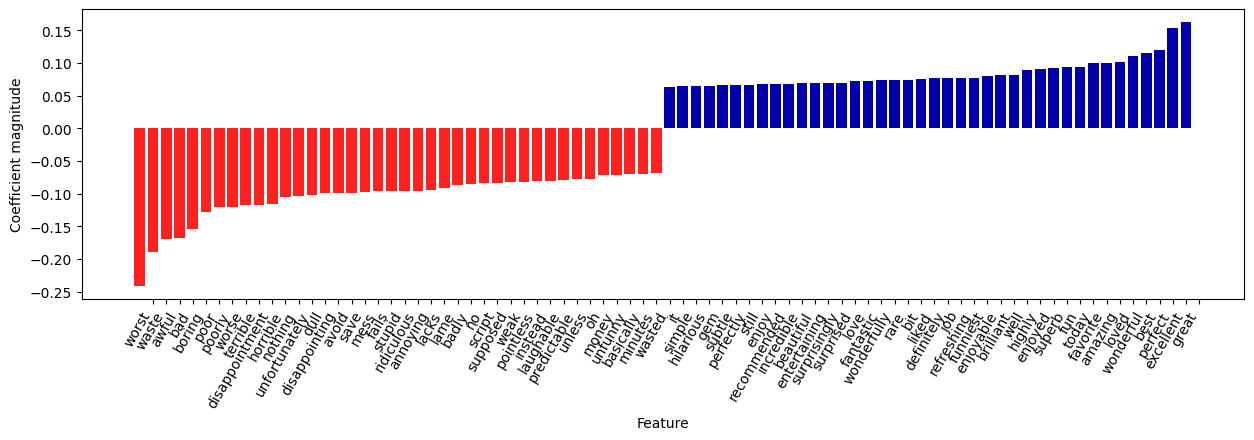

In [25]:
mglearn.tools.visualize_coefficients(
    grid.best_estimator_.named_steps["logisticregression"].coef_,
    feature_names, n_top_features=40)

The model's coefficients effectively distinguish between sentiments, where negative values on the left correspond to terms indicative of poor reviews, and positive values on the right align with favorable feedback. While many of these associations are highly intuitive—with descriptors like 'worst' and 'disappointment' signaling negative critiques, and 'excellent' or 'refreshing' marking positive ones—certain terms such as 'bit' or 'today' appear less definitive in isolation. However, these likely derive their sentiment from being embedded within broader contextual phrases, such as 'good job' or 'best today,' which the model successfully captures during the feature weighting process.

### **4.1. Bag-of-Words with More Than One Word (n-Grams)**

A significant limitation of the bag-of-words model lies in its disregard for word order, which can lead to identical representations for sentences with opposite meanings, such as 'it’s bad, not good at all' versus 'it’s good, not bad at all.' To address this loss of contextual nuance, we can incorporate n-grams—sequences of adjacent tokens like bigrams (pairs) or trigrams (triplets)—into our feature set. In practice, this is easily implemented by adjusting the ngram_range parameter in CountVectorizer or TfidfVectorizer, where we define a tuple representing the minimum and maximum sequence lengths to be captured, thereby allowing the model to better account for the linguistic context that single tokens often miss.

In [26]:
print("bards_words:\n{}".format(bards_words))

bards_words:
['The fool doth think he is wise,', 'but the wise man knows himself to be a fool']


The default is to create one feature per sequence of tokens that is at least one token long and at most one token long, or in other words exactly one token long (single tokens are also called unigrams):

In [27]:
cv = CountVectorizer(ngram_range=(1, 1)).fit(bards_words)
print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary:\n{}".format(cv.get_feature_names_out().tolist()))

Vocabulary size: 13
Vocabulary:
['be', 'but', 'doth', 'fool', 'he', 'himself', 'is', 'knows', 'man', 'the', 'think', 'to', 'wise']


With unigrams, we get the same 13 words. Each captures only a single word's presence: the model knows "fool", "wise", "the", and "man" all appeared, but it cannot distinguish "the fool" from "the wise man." To capture word pairs, we set ngram_range to $(2, 2)$:

In [28]:
cv = CountVectorizer(ngram_range=(2, 2)).fit(bards_words)
print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary:\n{}".format(cv.get_feature_names_out().tolist()))

Vocabulary size: 14
Vocabulary:
['be fool', 'but the', 'doth think', 'fool doth', 'he is', 'himself to', 'is wise', 'knows himself', 'man knows', 'the fool', 'the wise', 'think he', 'to be', 'wise man']


With bigrams only, the vocabulary grows to 14 two-word features. Notice something powerful: there is no common bigram between the two phrases. "the fool" only appears in the first string, "the wise" only in the second. Compare this to unigrams where "the", "fool", and "wise" were all shared -- bigrams are far more discriminative. The bigrams preserve local word order: "the fool" and "fool the" would be separate features. The dense representation confirms the complete separation:

In [29]:
print("Transformed data (dense):\n{}".format(cv.transform(bards_words).toarray()))

Transformed data (dense):
[[0 0 1 1 1 0 1 0 0 1 0 1 0 0]
 [1 1 0 0 0 1 0 1 1 0 1 0 1 1]]


In most practical applications, maintaining a minimum token count of one is essential since individual words frequently carry significant semantic weight; however, incorporating bigrams generally enhances model performance. While extending this up to 5-grams may provide further benefits, it often triggers a substantial expansion of the feature space, which risks overfitting due to the emergence of overly specific patterns. Theoretically, the feature space grows exponentially—where bigrams can reach the square of unigrams and trigrams the cube—yet the actual occurrence of these higher-order n-grams is somewhat mitigated by the inherent linguistic structure of English. Nevertheless, the resulting dimensionality remains considerable, as evidenced by the following implementation of unigrams, bigrams, and trigrams on the bards_words dataset.

In [30]:
cv = CountVectorizer(ngram_range=(1, 3)).fit(bards_words)
print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary:\n{}".format(cv.get_feature_names_out().tolist()))

Vocabulary size: 39
Vocabulary:
['be', 'be fool', 'but', 'but the', 'but the wise', 'doth', 'doth think', 'doth think he', 'fool', 'fool doth', 'fool doth think', 'he', 'he is', 'he is wise', 'himself', 'himself to', 'himself to be', 'is', 'is wise', 'knows', 'knows himself', 'knows himself to', 'man', 'man knows', 'man knows himself', 'the', 'the fool', 'the fool doth', 'the wise', 'the wise man', 'think', 'think he', 'think he is', 'to', 'to be', 'to be fool', 'wise', 'wise man', 'wise man knows']


Let’s try out the TfidfVectorizer on the IMDb movie review data and find the best setting of n-gram range using a grid search:

In [31]:
pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression(max_iter=5000))
# running the grid search takes a long time because of the
# relatively large grid and the inclusion of trigrams
param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100],
              "tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)]}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters:\n{}".format(grid.best_params_))

Best cross-validation score: 0.88
Best parameters:
{'logisticregression__C': 10, 'tfidfvectorizer__ngram_range': (1, 3)}


As you can see from the results, we improved performance by a bit more than a percent by adding bigram and trigram features. We can visualize the cross-validation accuracy as a function of the ngram_range and C parameter as a heat map

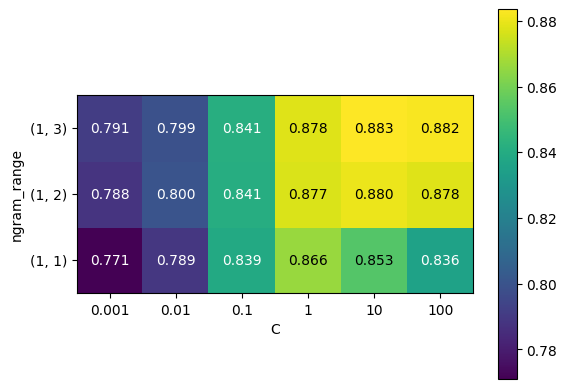

In [32]:
# extract scores from grid_search
scores = grid.cv_results_['mean_test_score'].reshape(-1, 3).T
# visualize heat map
heatmap = mglearn.tools.heatmap(
    scores, xlabel="C", ylabel="ngram_range", cmap="viridis", fmt="%.3f",
    xticklabels=param_grid['logisticregression__C'],
    yticklabels=param_grid['tfidfvectorizer__ngram_range'])
plt.colorbar(heatmap)

From the heat map we can see that using bigrams increases performance quite a bit, while adding trigrams only provides a very small benefit in terms of accuracy. To understand better how the model improved, we can visualize the important coefficient for the best model, which includes unigrams, bigrams, and trigrams:

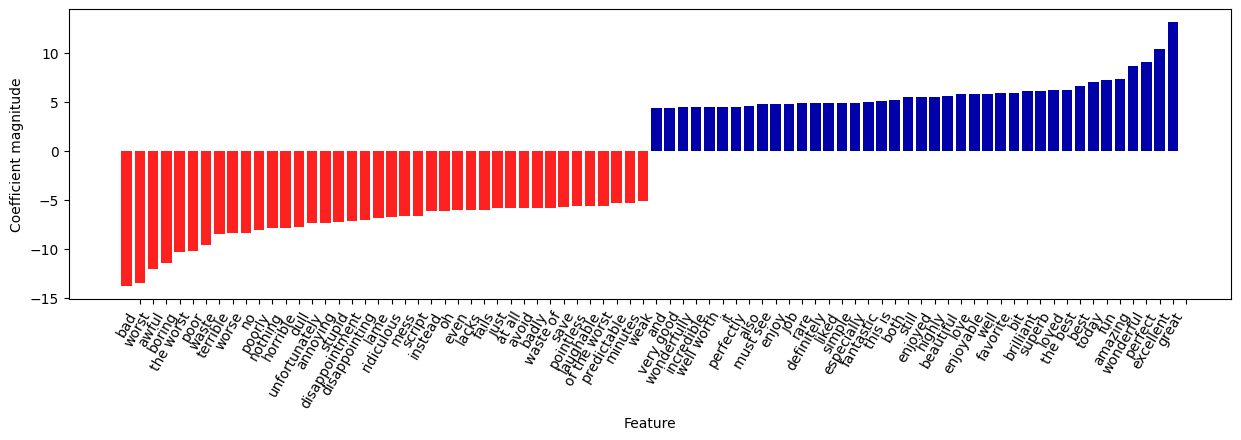

In [33]:
# extract feature names and coefficients
vect = grid.best_estimator_.named_steps['tfidfvectorizer']
feature_names = np.array(vect.get_feature_names_out())
coef = grid.best_estimator_.named_steps['logisticregression'].coef_
mglearn.tools.visualize_coefficients(coef, feature_names, n_top_features=40)

Interestingly, our analysis reveals specific features containing the word 'worth'—such as 'not worth' for negative sentiment and 'definitely worth' or 'well worth' for positive ones—which were notably absent in the unigram model, perfectly illustrating how context shifts a word's meaning. To better understand this utility, we will visualize the trigrams, as many effective higher-order n-grams frequently consist of common terms like 'none of the' or 'the only good' that lack standalone significance. Nevertheless, as illustrated in Figure 7-5, it is important to note that the overall impact of these bigram and trigram features remains relatively modest when compared to the foundational importance of unigram features.

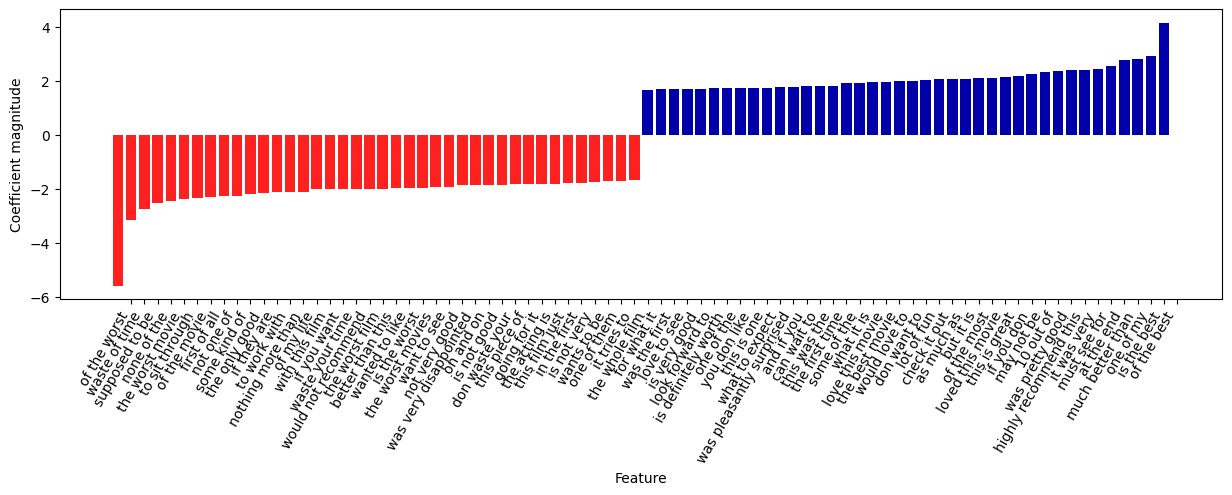

In [34]:
# find 3-gram features
mask = np.array([len(feature.split(" ")) for feature in feature_names]) == 3
# visualize only 3-gram features
mglearn.tools.visualize_coefficients(coef.ravel()[mask],
    feature_names[mask], n_top_features=40)

While certain trigrams—such as 'none of the' or 'waste of time'—capture nuanced sentiments that individual unigrams often fail to convey, their influence on the model remains relatively modest. This is evident from their coefficient magnitudes, which are generally smaller compared to those of unigrams and bigrams, suggesting that the model still heavily prioritizes simpler features for its primary predictions. Consequently, while bigrams provide a substantial boost in performance, incorporating trigrams results in only marginal refinements, as reflected in the minimal accuracy gains observed in our heatmap transitions.

## **5. Advanced Tokenization, Stemming, and Lemmatization**

While standard feature extraction methods like CountVectorizer and TfidfVectorizer are effective, their reliance on basic tokenization often leads to a redundant vocabulary where semantically similar words—such as singular/plural forms or various verb tenses—are treated as distinct entities. This lack of refinement can inadvertently cause overfitting and hinder a model's ability to generalize effectively from the training data. To mitigate this, we can implement text normalization techniques like stemming, which uses heuristic rules to truncate words to their stems, or the more linguistically precise lemmatization, which maps words to their dictionary forms (lemmas) based on context. By consolidating these morphological variations into a single representative token, we can simplify the feature space and focus the model on the core semantics of the text, much like how spelling correction functions to standardize input, though the latter remains a separate specialization in the broader preprocessing pipeline. Let's compare the Porter stemmer from NLTK:

In [35]:
import nltk

# instantiate nltk's Porter stemmer
stemmer = nltk.stem.PorterStemmer()

# define function to compare stemming behavior
def show_stemming(doc):
    words = doc.split()
    print("Original: ", words)
    print("Stemmed:  ", [stemmer.stem(w.lower()) for w in words])

show_stemming("Our meeting today was worse than yesterday")
print()
show_stemming("I am scared of meeting the clients tomorrow")

Original:  ['Our', 'meeting', 'today', 'was', 'worse', 'than', 'yesterday']
Stemmed:   ['our', 'meet', 'today', 'wa', 'wors', 'than', 'yesterday']

Original:  ['I', 'am', 'scared', 'of', 'meeting', 'the', 'clients', 'tomorrow']
Stemmed:   ['i', 'am', 'scare', 'of', 'meet', 'the', 'client', 'tomorrow']


The stemming results effectively highlight the trade-off between dimensionality reduction and linguistic accuracy, demonstrating how morphological variants like "meeting" and "clients" are successfully consolidated to streamline the vocabulary. While the Porter stemmer occasionally produces non-standard truncations such as "wa" or "wors," these remain functional for machine learning purposes as long as the mapping remains consistent across the feature set. However, unlike lemmatization—which leverages part-of-speech tagging to distinguish between nouns and verbs—stemming is context-blind and may over-simplify terms. Ultimately, while both methods serve as a form of regularization to prevent overfitting in smaller datasets by reducing the feature space $p$, their impact on larger corpora, such as our 25,000-review IMDb dataset, is often marginal since the model typically possesses sufficient data to naturally associate different word forms.

## **6. Topic Modeling and Document Clustering**

Topic modeling serves as a versatile unsupervised technique used to categorize text documents into one or more thematic subjects, much like how news articles are organized into sections such as politics or finance. When a document is restricted to a single category, the process is essentially a clustering task; however, when multiple topics are assigned, it aligns more closely with decomposition methods where each component represents a specific theme and its coefficients indicate the document’s topical relevance. Within this domain, researchers and practitioners most frequently utilize Latent Dirichlet Allocation (LDA) as the primary decomposition framework for identifying these underlying structures.

### **6.1. Latent Dirichlet Allocation**

Intuitively, the LDA model identifies latent themes by grouping frequently co-occurring words, treating each document as a proportional mixture of these underlying topics. However, it is crucial to distinguish these computational 'topics' from our everyday semantic definitions; much like the components in PCA or NMF, they represent statistical patterns that may capture anything from actual subject matter (e.g., sports or politics) to specific stylistic nuances, such as an individual author’s unique vocabulary. To ensure these patterns are meaningful when applied to our movie review dataset, we first refine our bag-of-words model by filtering out the most common terms—specifically those appearing in more than 20% of the documents—and focusing on the top 10,000 most frequent words to prevent the analysis from being skewed by ubiquitous language.

In [36]:
vect = CountVectorizer(max_features=10000, max_df=.15)
X = vect.fit_transform(text_train)

We will learn a topic model with 10 topics:

In [37]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=10, learning_method="batch",
                                max_iter=25, random_state=0)
# We build the model and transform the data in one step
document_topics = lda.fit_transform(X)

LatentDirichletAllocation has a components_ attribute that stores how important each word is for each topic. The size is $(K, p)$ where $K$ is the number of topics and $p$ is the vocabulary size:

In [38]:
print("lda.components_.shape: {}".format(lda.components_.shape))

lda.components_.shape: (10, 10000)


To understand better what the different topics mean, we will look at the most important words for each of the topics. The print_topics function provides a nice formatting for these features:

In [39]:
# For each topic (a row in the components_), sort the features (ascending)
# Invert rows with [:, ::-1] to make sorting descending
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]
# Get the feature names from the vectorizer
feature_names = np.array(vect.get_feature_names_out())

In [40]:
# Print out the 10 topics:
mglearn.tools.print_topics(topics=range(10), feature_names=feature_names,
                           sorting=sorting, topics_per_chunk=5, n_words=10)

topic 0       topic 1       topic 2       topic 3       topic 4       
--------      --------      --------      --------      --------      
family        music         comedy        world         thing         
father        musical       funny         war           worst         
young         role          cast          us            didn          
girl          cast          role          american      funny         
mother        john          performance   our           nothing       
woman         performance   actor         own           actually      
wife          songs         actors        history       10            
old           dance         plays         documentary   want          
son           star          played        real          got           
home          song          work          human         horror        


topic 5       topic 6       topic 7       topic 8       topic 9       
--------      --------      --------      --------      --------      
dire

Based on the prominent keywords identified, Topic 1 appears to revolve around historical and war cinema, while Topics 2 and 3 likely represent low-rated comedies and television series, respectively. Furthermore, Topic 4 captures general terminology, whereas Topics 6 and 8 focus on children's movies and award-centric reviews. Given the constraint of utilizing only ten topics, each category remains intentionally broad to encapsulate the diverse range of reviews within the dataset; however, to achieve a more granular and specialized analysis of these data subsets, we will now transition to a model featuring 100 topics, despite the inherent increase in analytical complexity.

In [41]:
lda100 = LatentDirichletAllocation(n_components=100, learning_method="batch",
                                   max_iter=25, random_state=0)
document_topics100 = lda100.fit_transform(X)

With 100 topics, we expect narrower, more interpretable themes. Let's examine a curated selection of interesting topics:

In [42]:
topics = np.array([7, 16, 24, 25, 28, 36, 37, 45, 51, 53, 54, 63, 89, 97])
sorting = np.argsort(lda100.components_, axis=1)[:, ::-1]
feature_names = np.array(vect.get_feature_names_out())
mglearn.tools.print_topics(topics=topics, feature_names=feature_names,
                           sorting=sorting, topics_per_chunk=7, n_words=20)

topic 7       topic 16      topic 24      topic 25      topic 28      topic 36      topic 37      
--------      --------      --------      --------      --------      --------      --------      
green         ring          church        footage       wife          gay           lady          
jim           team          faith         werewolf      husband       subject       romantic      
bruce         ball          victor        beast         family        between       grace         
world         angle         priest        stock         woman         social        ship          
heston        big           ford          wolf          daughter      art           titanic       
carrey        cruel         religion      mummy         home          sexual        shop          
edward        got           catholic      melting       married       rather        rose          
robinson      away          irish         shirt         mother        real          grant         
god       

The topics we extracted this time seem to be more specific, though many are hard to interpret. Topic 7 seems to be about horror movies and thrillers; topics 16 and 54 seem to capture bad reviews, while topic 63 mostly seems to be capturing positive reviews of comedies. If we want to make further inferences using the topics that were discovered, we should confirm the intuition we gained from looking at the highest ranking words for each topic by looking at the documents that are assigned to these topics. For example, topic 45 seems to be about music. Let’s check which kinds of reviews are assigned to this topic:

In [43]:
# sort by weight of "music" topic 45
music = np.argsort(document_topics100[:, 45])[::-1]
# print the five documents where the topic is most important
for i in music[:5]:
    # show first two sentences
    print(".".join(text_train[i].split(".")[:2]) + ".\n")

The title is onomatopoeic, the sound of a streetcar clacking on the rails. It is metaphoric for all that the people who live in the dump cannot have.

Alexandr "Sascha" Luzhin (John Turturro) is a former leading chess player attempting a comeback at an Italy-hosted tournament. His brilliance is unquestioned but his obsession with chess has stunted his growth in all other aspects of his life.

I was overtaken by the emotion. Unforgettable rendering of a wartime story which is unknown to most people.

Marlene Gorris has established herself as one of the world's great directors. This sensitive, visually beautiful film is based on a story by Vladimir Nabokov and captures well that writer's dark irony.

The movie is wonderful. It shows the man's work for the wilderness and a natural understanding of the harmony of nature, without being an "extreme" naturalist.



Based on our observation, this topic encompasses a diverse range of music-oriented reviews, spanning from stage musicals and biographical films to more ambiguous genres found in the final entries. To gain a broader perspective on these themes, we can analyze the overall prevalence of each topic by aggregating the 'document_topics' weights across the entire dataset. In this analysis, each topic is identified by its two most frequent terms, with the resulting distribution and relative importance of these learned topics.

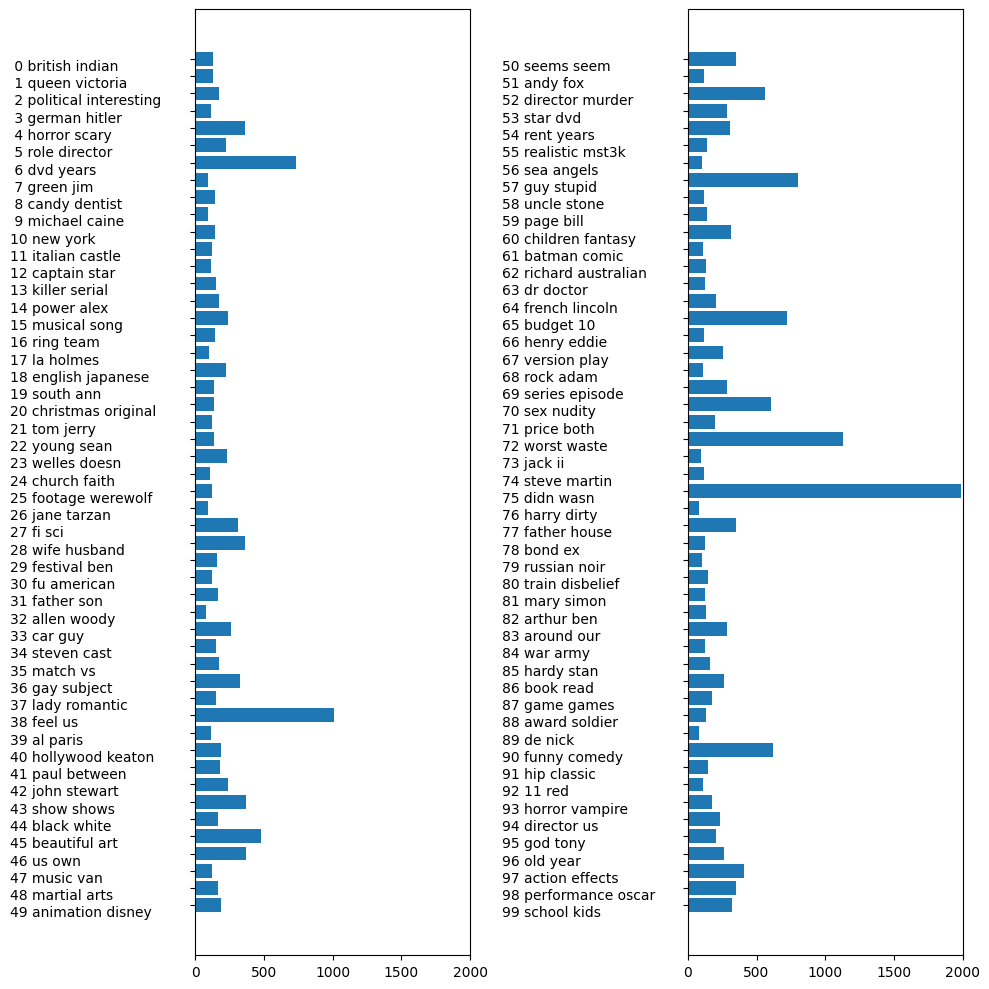

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
topic_names = ["{:>2} ".format(i) + " ".join(words)
               for i, words in enumerate(feature_names[sorting[:, :2]])]
# two column bar chart:
for col in [0, 1]:
    start = col * 50
    end = (col + 1) * 50
    ax[col].barh(np.arange(50), np.sum(document_topics100, axis=0)[start:end])
    ax[col].set_yticks(np.arange(50))
    ax[col].set_yticklabels(topic_names[start:end], ha="left", va="top")
    ax[col].invert_yaxis()
    ax[col].set_xlim(0, 2000)
    yax = ax[col].get_yaxis()
    yax.set_tick_params(pad=130)
plt.tight_layout()

Our LDA analysis reveals a clear distinction between genre-specific and rating-specific topics, with Topic 97 appearing to be primarily noise from stopwords, while Topic 16 and Topics 36-37 represent negative and laudatory reviews, respectively. This dual focus is particularly insightful as it mirrors the natural composition of movie reviews, which typically blend thematic content with evaluative sentiment. While LDA proves to be a powerful tool for uncovering latent structures in large corpora—even when labels are available—it is important to remember that the randomized nature of the algorithm means results can vary with different states. Therefore, while these topics can serve as a compact representation for supervised learning in low-data scenarios, any qualitative conclusions should be validated by inspecting the original documents to ensure our intuition aligns with the model's output.

### **7. Summary**

### **The Crucial Role of Text Processing**

This chapter introduced the fundamentals of Natural Language Processing (NLP) within the context of machine learning. Handling text requires specialized preprocessing steps to bridge the gap between human language and mathematical algorithms. There are several key points to keep in mind:

- Representation is Everything: The way you choose to represent your text data is absolutely key in NLP applications. Simple representations like bag-of-words offer powerful solutions for tasks like spam detection and sentiment analysis.

- Model Introspection: Text processing allows for high interpretability. By inspecting the extracted tokens, n-grams, and model coefficients, practitioners can gain profound insights into what the model is learning and why it makes certain decisions.

- Beyond Simple Counts: While simple frequency counts are a great baseline, modern NLP heavily relies on advanced techniques like continuous vector representations (word2vec) and Recurrent Neural Networks (RNNs) for complex tasks like automatic translation.

### **Key Concepts**

- **Bag-of-Words** A feature extraction method that ignores text structure and order, creating a feature array that simply counts how often each vocabulary word appears in a given document.

- **Sparse Matrix** Because most documents contain only a tiny subset of the English vocabulary, text data features are stored in sparse matrices that only record nonzero entries to save memory.

- **Stopwords** Common, uninformative words (e.g., "the", "is") that can be explicitly discarded to reduce the feature space without losing predictive power.

- **tf-idf (Term Frequency-Inverse Document Frequency)** A rescaling technique that emphasizes terms that are highly frequent in a specific document but rare in the overall dataset, identifying words that truly distinguish a text.

- **n-Grams** Sequences of adjacent tokens (unigrams are single words, bigrams are pairs, trigrams are triplets) used to capture context and word order that standard bag-of-words misses.

- **Stemming and Lemmatization** Normalization techniques that conflate different forms of the same word into a single root representation. Stemming uses rigid heuristic rules, while lemmatization utilizes dictionaries and grammatical context.

- **Latent Dirichlet Allocation (LDA)** A randomized, unsupervised topic modeling algorithm that groups frequently co-occurring words into "topics" and represents documents as a mixture of these topics.